In [1]:
#Configuration
import osmnx as ox
import geopandas as gpd
import pandas as pd
from pyrosm import OSM
from shapely.geometry import Polygon

BASE = "/home/jovyan/work/children15mc"
RAW = f"{BASE}/data/raw"
PROC = f"{BASE}/data/processed"
FIG = f"{BASE}/outputs/figures"
LOCAL_PBF = f"{RAW}/greater-london-260812.osm.pbf"

ox.settings.use_cache = True
ox.settings.cache_folder = f"{BASE}/cache"

lsoa = gpd.read_file(f"{PROC}/lsoa_london.gpkg")
london_area = lsoa.union_all()
print("Configuration complete.")

Configuration complete.


In [2]:
#1. School: Filter out the primary schools
sch = pd.read_csv(f"{RAW}/schools_england.csv", encoding="latin1")
sch = sch[
    (sch["PhaseOfEducation (name)"] == "Primary") &
    (sch["EstablishmentStatus (name)"] == "Open") &
    (sch["Easting"].notna())
].copy()
schools = gpd.GeoDataFrame(
    sch, geometry=gpd.points_from_xy(sch["Easting"], sch["Northing"]), crs=27700)
print(f"English primary school(Open): {len(schools)}")

lsoa = gpd.read_file(f"{PROC}/lsoa_london.gpkg")
london_area = lsoa.union_all()
schools = schools[schools.within(london_area)].copy()
print(f"London Primary School: {len(schools)}")

schools[["EstablishmentName", "geometry"]].to_file(
    f"{PROC}/schools_london.gpkg", driver="GPKG")
print("School saved")

/tmp/ipykernel_151843/1667555188.py:2: DtypeWarning: Columns (48,51,69,70,71,124,129,134) have mixed types. Specify dtype option on import or set low_memory=False.
  sch = pd.read_csv(f"{RAW}/schools_england.csv", encoding="latin1")


English primary school(Open): 16669
London Primary School: 1752
School saved


In [3]:
#2. Parks: extract polygons and generate entry points
osm = OSM(LOCAL_PBF)
parks_data = osm.get_data_by_custom_criteria(custom_filter={"leisure": ["park"]})
parks = parks_data[parks_data.geometry.type.isin(["Polygon", "MultiPolygon"])].to_crs(27700)
parks = parks.reset_index(drop=True).reset_index().rename(columns={"index": "park_id"})
parks = parks[["park_id", "geometry"]]
print(f"London parks: {len(parks)}")

# Tagged gates / entrances
gates_data = osm.get_data_by_custom_criteria(
    custom_filter={"barrier": ["gate"], "entrance": ["yes", "main"]})
entry_pts = gates_data[gates_data.geometry.type == "Point"].to_crs(27700)
print(f"Tagged gates/entrances: {len(entry_pts)}")

# Match tagged points to parks (within 20 m of boundary)
park_buf = parks.copy()
park_buf["geometry"] = park_buf.geometry.boundary.buffer(20)
matched = gpd.sjoin(entry_pts, park_buf[["park_id", "geometry"]],
                    how="inner", predicate="within")[["park_id", "geometry"]].drop_duplicates()
n_tagged = matched["park_id"].nunique()
print(f"Parks with tagged entrances: {n_tagged} ({100*n_tagged/len(parks):.1f}%)")

# Boundary sampling for the rest
have = set(matched["park_id"])
missing = parks[~parks["park_id"].isin(have)]
rows = []
for _, r in missing.iterrows():
    bnd = r.geometry.boundary
    lines = [bnd] if bnd.geom_type == "LineString" else list(bnd.geoms)
    for ln in lines:
        n = max(int(ln.length // 25), 1)
        for i in range(n):
            rows.append({"park_id": r["park_id"], "geometry": ln.interpolate(i * 25)})

sampled = gpd.GeoDataFrame(rows, crs=27700) if rows else gpd.GeoDataFrame(geometry=[], crs=27700)
park_entries = gpd.GeoDataFrame(pd.concat([matched, sampled], ignore_index=True), crs=27700)
print(f"Total park entry points: {len(park_entries)}")
park_entries.to_file(f"{PROC}/park_entries.gpkg", driver="GPKG")

London parks: 3250
Tagged gates/entrances: 72853
Parks with tagged entrances: 1697 (52.2%)
Total park entry points: 30791


In [4]:
# 3. Calculate Child 15mC Score
iso = gpd.read_file(f"{PROC}/isochrones_all.gpkg")
schools = gpd.read_file(f"{PROC}/schools_london.gpkg")
park_entries = gpd.read_file(f"{PROC}/park_entries.gpkg")

print(f"Isochrones {len(iso)}, Schools {len(schools)}, Park entries {len(park_entries)}")

js = gpd.sjoin(schools, iso, how="inner", predicate="within")
n_schools = js.groupby("lsoa21cd").size().rename("n_schools")

jp = gpd.sjoin(park_entries, iso, how="inner", predicate="within")
n_parks = jp.groupby("lsoa21cd")["park_id"].nunique().rename("n_parks")

iso = iso.merge(n_schools, on="lsoa21cd", how="left")
iso = iso.merge(n_parks, on="lsoa21cd", how="left")
iso[["n_schools","n_parks"]] = iso[["n_schools","n_parks"]].fillna(0).astype(int)
iso["c15mc_score"] = iso["n_schools"] + iso["n_parks"]

print(iso[["n_schools","n_parks","c15mc_score"]].describe().round(2))

Isochrones 4994, Schools 1752, Park entries 30791
       n_schools  n_parks  c15mc_score
count    4994.00  4994.00      4994.00
mean        2.31     4.82         7.13
std         1.66     4.90         5.88
min         0.00     0.00         0.00
25%         1.00     2.00         3.00
50%         2.00     3.00         6.00
75%         3.00     6.00         9.00
max        11.00    36.00        43.00


In [5]:
#4. Merge scores back into the main analysis table
df = gpd.read_file(f"{PROC}/analysis_table.gpkg")
scores = iso[["lsoa21cd", "n_schools", "n_parks", "c15mc_score"]]
df = df.merge(scores, on="lsoa21cd", how="left")

for c in ["n_schools", "n_parks", "c15mc_score"]:
    df[c] = df[c].fillna(0).astype(int)

df.to_file(f"{PROC}/accessibility.gpkg", driver="GPKG")
print(df[["lsoa21cd","lad22nm","idaci_score","c15mc_score"]].head())

    lsoa21cd               lad22nm  idaci_score  c15mc_score
0  E01000011  Barking and Dagenham        0.189            4
1  E01000046  Barking and Dagenham        0.208            3
2  E01000051  Barking and Dagenham        0.322           13
3  E01000077  Barking and Dagenham        0.294            3
4  E01000083  Barking and Dagenham        0.249            5


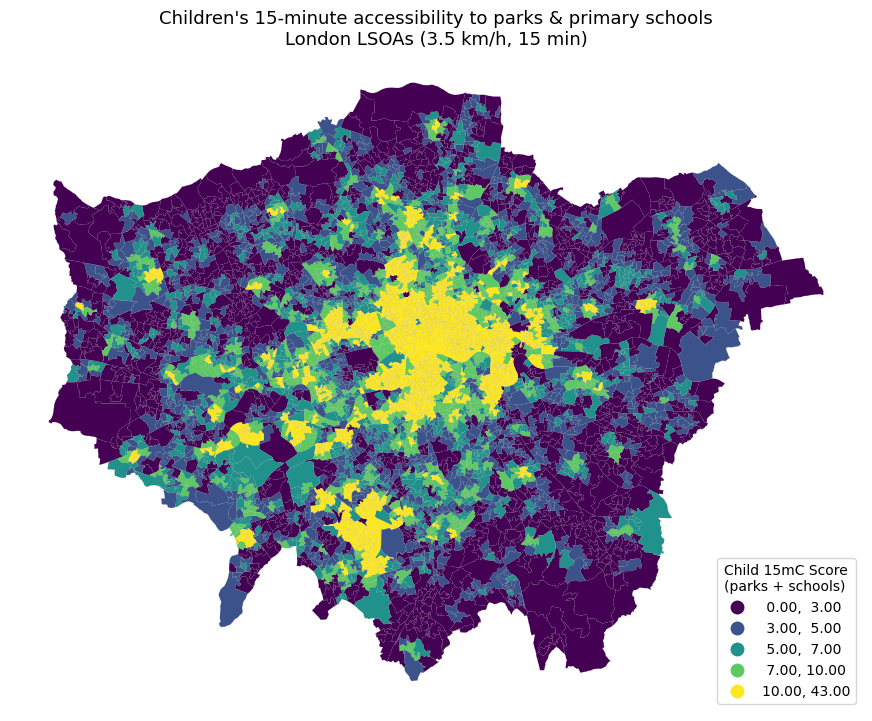

In [6]:
#5. City accessibility map
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 11))
df.plot(column="c15mc_score", cmap="viridis", legend=True,
        scheme="quantiles", k=5, linewidth=0.05, edgecolor="gray", ax=ax,
        legend_kwds={"title": "Child 15mC Score\n(parks + schools)", "loc": "lower right"})
ax.set_title("Children's 15-minute accessibility to parks & primary schools\nLondon LSOAs (3.5 km/h, 15 min)", fontsize=13)
ax.set_axis_off()
plt.savefig(f"{FIG}/accessibility_map.png", dpi=150, bbox_inches="tight")
plt.show()